In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [21]:
class Value:
    def __init__(self,data, _children = (), _op="", _label= ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda:None
        self._label = _label
        self.grad = 0.0
        
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __radd__(self,other):
        return self+other
        
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other),"+")
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
        
    def __sub__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        return self.data + (-other)
        
    def __rmul__(self,other):
        return self*other
        
    def __truediv__(self, other):
        return self * (other**-1)
        
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other),"*")  
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __neg__(self):
        return self * -1
    def __pow__(self, other):
        assert isinstance(other, (int, float)) , "only supporting int/ float"
        out = Value(self.data**other, (self,), _label =f"**{other}")
        
        def _backward():
            self.grad += out.grad* other*self.data**(other-1)
        out._backward = _backward
        return out
        
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")
        def _backward():
            self.grad = out.data*out.grad
        out._backward = _backward
        return out
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1)/(math.exp(2*x) +1)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad = (1-t**2) * out.grad
        out._backward = _backward
        return out
    
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [3]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges
def draw_dot(root):
    dot = Digraph(format = "svg", graph_attr = {"rankdir":"LR"})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}"% (n._label,n.data,n.grad), shape = "record")
        if n._op:
            dot.node(name=uid+n._op, label =n._op)
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+ n2._op)
    return dot

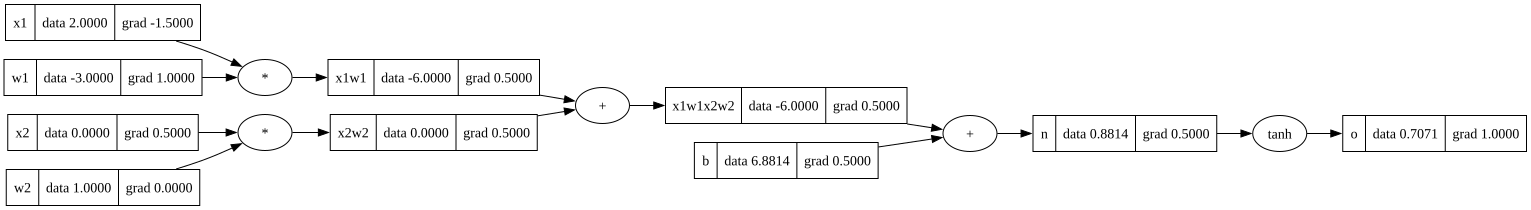

In [4]:
# inputs
x1 = Value(2.0, _label = "x1")
x2 = Value(0.0, _label = "x2")
# weights
w1 = Value(-3.0, _label = "w1")
w2 = Value(1.0, _label = "w2")
# bias of the neuron
b = Value(6.8813725870195432, _label = "b")
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1._label= "x1w1"
x2w2 = x2*w2; x2w2._label= "x2w2"
x1w1x2w2 = x1w1+x2w2; x1w1x2w2._label= "x1w1x2w2"
n = x1w1x2w2 + b; n._label = "n"
o = n.tanh(); o._label = "o"
o.backward()
draw_dot(o)

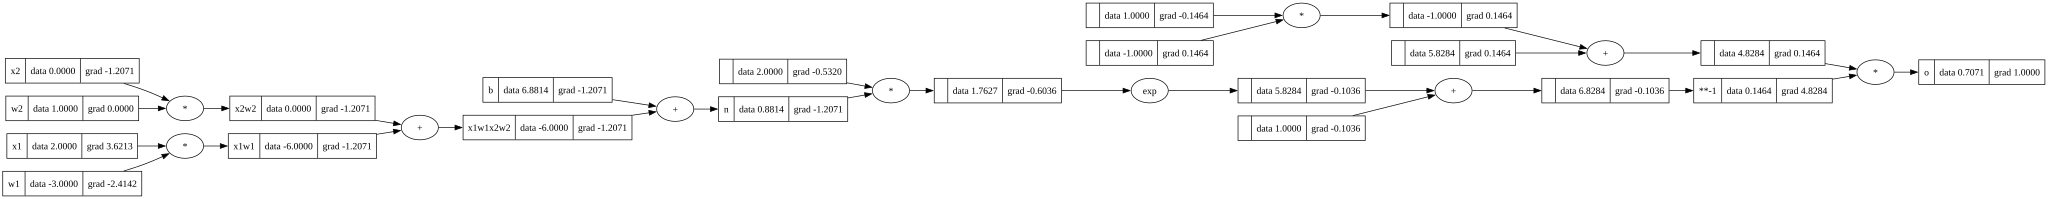

In [22]:
# inputs
x1 = Value(2.0, _label = "x1")
x2 = Value(0.0, _label = "x2")
# weights
w1 = Value(-3.0, _label = "w1")
w2 = Value(1.0, _label = "w2")
# bias of the neuron
b = Value(6.8813725870195432, _label = "b")
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1._label= "x1w1"
x2w2 = x2*w2; x2w2._label= "x2w2"
x1w1x2w2 = x1w1+x2w2; x1w1x2w2._label= "x1w1x2w2"
n = x1w1x2w2 + b; n._label = "n"
# -----
e = (2*n).exp()
o = (e-1)/(e+1); 
# -----
o._label = "o"
o.backward()
draw_dot(o)

In [29]:
import torch

x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.881373587019]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())


0.7071066904050358


In [30]:
class Neurons:
    def __init__(self,min):
        self.w = (Value(random.arange(-1,0,1)) for i in range(min))
        self.b = (Value(random.arange(-1,0,1)))
    def call(self, x):
        # wx + b
        act = sum(wi*xi for wi,xi in zip(self.w,x)) + self.b 
        return 0.0